# OOP in Python: when should we use classes?

Today we will **not** learn every detail about `class`. The goal is simpler:

> understand when a **function** is enough VS when a **class** makes the code clearer

By the end of the session you should be able to decide whether your Python code should be solved with:
- a function,
- multiple functions,
- a dictionary, or
- a class

## Small recap until now

(Last session before your projects)

So far, you've learned:
* Create your own environment and use Jupyter notebooks
* Fix problems in your BAM laptops
* Core Python syntax: variables, types (str, int, float, complex, bool)
* Advanced types: lists, dictionaries, tuples, sets
* Basics about functions (`def ...`), loops (`for ...`), conditionals (`if... elif... else...`)

Not only that, now you should be able to:
* Open and read the contents of a file
* Work with Python packages, e.g., `numpy`, `pandas`, and plot lists/arrays with `matplotlib`
* Work with paths instead of hardcoding stuff with `pathlib`

And you've also learned some basics on:
* Organizing your projects
* How to write proper Python code, with a clear style and formatting
* Use automated quality packages like `ruff` and `mypy`

In [1]:
def calculate_average(values: list) -> float:
    return sum(values) / len(values) if values else print("The list is empty, cannot calculate average.")

In [2]:
measurements = [10.2, 10.5, 10.3, 10.4, 10.1]
average = calculate_average(measurements)
print(average)

10.3


This is a good example of a function:
1. The operation is clear
2. The function has **one** job
3. It does not need to remember anything
4. Input and output are obvious

--> for many problems, functions like this are enough

In [4]:
def is_valid_measurement(value: float) -> bool:
    return value >= 0.0


print(is_valid_measurement(10.5))
print(is_valid_measurement(-5.0))

True
False


Exercise 1 - Write a function `normalize_values()`. It should receive a list of numbers as input and reutnr a new list where each value is divided by its maximum value (normalize to the max)

In [5]:
def normalize_values(values: list) -> list:
    if not values:
        print("The list is empty, cannot normalize values.")
        return []
    min_value = min(values)
    max_value = max(values)
    range_value = max_value - min_value
    if range_value == 0:
        print("All values are the same, cannot normalize.")
        return [0.0] * len(values)
    return [(value - min_value) / range_value for value in values]

In [11]:
print(f"My measurements are: {measurements}, and their normalized values (to the max, {max(measurements)}) are: {normalize_values(measurements)}")

My measurements are: [10.2, 10.5, 10.3, 10.4, 10.1], and their normalized values (to the max, 10.5) are: [0.2499999999999989, 1.0, 0.5000000000000022, 0.7500000000000011, 0.0]


Other examples where functions are enough:
- calculate_average(values)
- convert_celsius_to_kelvin(value)
- plot_histogram(values)
- read_csv_file(path)
- validate_temperature(value)

--> This is called 🌟🌟**FUNCTIONAL PROGRAMMING**🌟🌟

### Functional vs. Object-Oriented Programming (OOP)

In reality, a measurement is more than its values as a list.

It may have:
- a sample name,
- an operator,
- a measured value,
- the values have units,
- an instrument,
- a date when the measurement was obtained, and
- validation rules (e.g., values >= 0.0 always)

#### Option 1 - Functional programming

In [19]:
# several variables
sample_name = "Sample A"
measurements = [10.2, 10.5, 10.3, 10.4, 10.1]
unit = "kelvin"
operator = "Dr Mustermann"
instrument = "Thermometer 3000"
# or even a dictionary
measurement = {
    "sample_name": "Sample A",
    "values": [10.2, 10.5, 10.3, 10.4, 10.1],
    "unit": "kelvin",
    "operator": "Dr Mustermann",
    "instrument": "Thermometer 3000"
}

# + associated functions
def is_valid_measurement(values: list) -> bool:
    return all(value >= 0.0 for value in values)

def describe_measurement(measurement):
    return f"{measurement['sample_name']}: {measurement['values']} {measurement['unit']}"

def calculate_average(values: list) -> float:
    return sum(values) / len(values) if values else print("The list is empty, cannot calculate average.")

In [21]:
is_valid_measurement(measurement['values'])

True

In [22]:
describe_measurement(measurement)

'Sample A: [10.2, 10.5, 10.3, 10.4, 10.1] kelvin'

In [23]:
calculate_average(measurement['values'])

10.3

This is fine for small scripts

When scaling up, i.e., when your code becomes more complex --> this is harder to read, debug, and, overall, maintain!

#### Option 2 - OOP (classes/objects)

A `class Measurement` can be useful when:
- several values belong together (as in a dictionary),
- the same operations are applied to those values,
- we want to create many similar things,
- we want a clearer domain model

> a class is useful when we want to model a *concept* (class), not just perform *singular, separated actions* (function)

In [86]:
class Measurement:
    def __init__(self):
        print("Measurement object created.")

In [87]:
# this is an `object`
print(Measurement, type(Measurement))
print(str, type(str))  # left ctrl + click on the class name to see its definition

<class '__main__.Measurement'> <class 'type'>
<class 'str'> <class 'type'>


In [88]:
# this is an `instance` of the `object` Measurement
print(Measurement(), type(Measurement()))

Measurement object created.
Measurement object created.
<__main__.Measurement object at 0x000002059467E660> <class '__main__.Measurement'>


In [89]:
class Measurement:
    def __init__(self, sample_name: str, values: list, unit: str, operator: str, instrument: str):
        # `attributes` are variables that belong to the class
        self.sample_name = sample_name  
        self.values = values
        self.unit = unit
        self.operator = operator
        self.instrument = instrument

In [91]:
measurement = Measurement(sample_name="Sample A", values=[10.2, 10.5, 10.3, 10.4, 10.1], unit="kelvin", operator="Dr Mustermann", instrument="Thermometer 3000")
print(measurement)

In [27]:
print(measurement.sample_name, measurement.values, measurement.unit, measurement.operator, measurement.instrument)

Sample A [10.2, 10.5, 10.3, 10.4, 10.1] kelvin Dr Mustermann Thermometer 3000


In [55]:
class Measurement:
    def __init__(self, sample_name: str, values: list, unit: str, operator: str, instrument: str):
        # `attributes` are variables that belong to the class
        self.sample_name = sample_name
        self.values = values
        self.unit = unit
        self.operator = operator
        self.instrument = instrument

    # `methods` are functions that belong to the class
    def is_valid(self) -> bool:  
        return all(value >= 0.0 for value in self.values)

    def describe(self) -> str:
        return f"{self.sample_name}: {self.values} {self.unit}"

    def calculate_average(self) -> float:
        return sum(self.values) / len(self.values) if self.values else print("The list is empty, cannot calculate average.")

In [51]:
measurement_1 = Measurement(sample_name="Sample A", values=[10.2, 10.5, 10.3, 10.4, 10.1], unit="kelvin", operator="Dr Mustermann", instrument="Thermometer 3000")
measurement_1.is_valid()

True

In [40]:
measurement_1.describe()

'Sample A: [10.2, 10.5, 10.3, 10.4, 10.1] kelvin'

In [41]:
measurement_1.calculate_average()

10.3

In [45]:
measurement_2 = Measurement(sample_name="Sample B", values=[-5.0, 10.5, 10.3, 10.4, 10.1], unit="kelvin", operator="Dr Mustermann", instrument="Thermometer 3000")

In [46]:
measurement_2.is_valid()

False

In [47]:
measurement_1.sample_name == measurement_2.sample_name

False

In [49]:
measurement_1.instrument == measurement_2.instrument

True

#### What changed?

Before:
```python
is_valid_measurement(measurement)
describe_measurement(measurement)
```

Now:
```python
measurement = Measurement(...)
measurement.is_valid()
measurement.describe()
```

The instance `measurement` constains both:
- the data
- the behavior related to the data

--> this makes the code **much** easier to read

#### Classes are not automatically better

In [58]:
class AverageCalculator:  # bad design
    def calculate_average(self, values: list) -> float:
        return sum(values) / len(values) if values else print("The list is empty, cannot calculate average.")
    

def calculate_average(values: list) -> float:  # better design
    return sum(values) / len(values) if values else print("The list is empty, cannot calculate average.")

In general:
> if you can do things (action) with one function, you do not need a class

But:
> if you can create a class to model a concept + their functions, this is much better code design!

Exercise 2 - Look at the examples below and decide whether to do a `function`, a `dictionary`, or a `class`

In [67]:
# Convert Celsius to Kelvin  --> function

# Represent a sample with name (str), owner (str), and storage location (str)  --> dictionary or class

# Plot a list of values after transforming them to be normalized to the maximum value in the list  --> function or class

# Represent an instrument with name(str), serial number (str), and calibration date (str), and check if the calibration date is valid (not in the future)  --> class

Exercise 3 - Suppose we measure a sample multiple times. We want to:
1. Store sample_name (str), values (list of floats), and the units of the values (str)
2. Validate that values are always positive
3. Validate that units can only be "kelvin" or "celsius"
4. If someone passes units to be "fahrenheit", print a message

We also want to calculate:
1. Average of the values
2. The minimum
3. The maximum

And we want to do a small plot for its values.

In [63]:
def plot_measurements(values: list):
    import matplotlib.pyplot as plt
    if not values:
        print("The list is empty, cannot plot measurements.")
        return
    plt.plot(values)
    plt.title("Measurements")
    plt.xlabel("Index")
    plt.ylabel("Value")
    plt.show()

In [64]:
class Measurement:
    def __init__(self, sample_name: str, values: list, unit: str):
        self.sample_name = sample_name
        self.values = values
        self.unit = unit

    def is_valid(self) -> bool:
        return all(value >= 0.0 for value in self.values)

    def unit_is_valid(self) -> bool:
        valid_units = ["kelvin", "celsius", "fahrenheit"]
        if self.unit.lower() == "fahrenheit":
            print("Warning: Fahrenheit is a very dumb unit to use; please, revise your life choices and define a proper unit for your measurements.")
        return self.unit.lower() in valid_units
    
    def average(self) -> float:
        return sum(self.values) / len(self.values) if self.values else print("The list is empty, cannot calculate average.")
    
    def minimum(self) -> float:
        return min(self.values) if self.values else print("The list is empty, cannot calculate minimum value.")
    
    def maximum(self) -> float:
        return max(self.values) if self.values else print("The list is empty, cannot calculate maximum value.")

In [65]:
measurement = Measurement(sample_name="Sample A", values=[10.2, 10.5, 10.3, 10.4, 10.1], unit="kelvin")
print(measurement.is_valid())

True


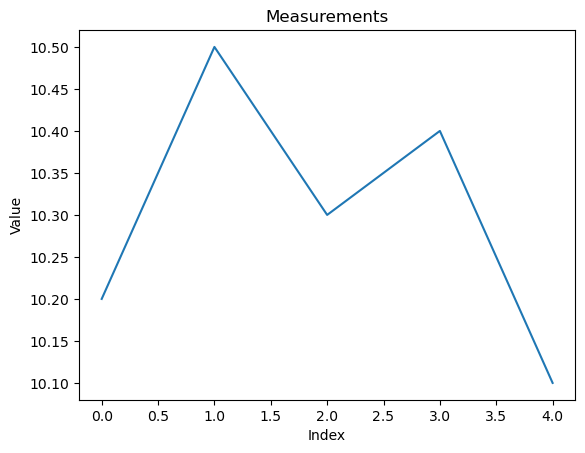

In [ ]:
plot_measurements(measurement.values)

In practice, code contains both solutions. It may even evolve, and what was first a function can become later a class.

Try always answering: 
1. What I want short-term
2. What I predict I'll need long-term
3. What is easier to read and maintain if I come back later

In [92]:
# Avoid hardcoded stuff

# Good, but hardcoded stuff
class Instrument:
    def __init__(self, name, serial_number, calibration_year):
        self.name = name
        self.serial_number = serial_number
        self.calibration_year = calibration_year

    def needs_calibration(self):
        return self.calibration_year < 2025


instrument = Instrument("Balance", "B-123", 2023)
print(instrument.needs_calibration())


# Better design
class Instrument:
    def __init__(self, name, serial_number, calibration_year):
        self.name = name
        self.serial_number = serial_number
        self.calibration_year = calibration_year

    def needs_calibration(self):
        return self.calibration_year < 2025


instrument = Instrument("Balance", "B-123", 2023)
print(instrument.needs_calibration())

True
True


### Inheritance and Abstraction

OOP has a very important concept that makes it more useful than what we saw so far: **inheritance**.
Other buzzwords related to inheritance in OOP are: abstraction, polymorphism, composition

In [96]:
class XRayInstrument(Instrument):
    def __init__(self, name, serial_number, calibration_year, xray_source):
        super().__init__(name, serial_number, calibration_year)
        self.xray_source = xray_source

    def needs_calibration(self):
        return super().needs_calibration() or self.xray_source == "old_rotating_anode"
    
    def xray_source_is_valid(self):
        valid_sources = ["new_rotating_anode", "old_rotating_anode", "sealed_tube", "microfocus", "BESSY"]
        return self.xray_source in valid_sources
    

XRayInstrument("X-Ray Diffractometer", "XRD-456", 2022, "old_rotating_anode")

In [99]:
class XRayInstrument(Instrument):
    def __init__(self, name, serial_number, calibration_year, xray_source):
        super().__init__(name, serial_number, calibration_year)
        self.xray_source = xray_source

        print(f"Does it need radiation safety check? {"Yes" if self.requires_radiation_safety_check() else "No"}")

    def needs_calibration(self):
        return super().needs_calibration() or self.xray_source == "old_rotating_anode"
    
    def xray_source_is_valid(self):
        valid_sources = ["new_rotating_anode", "old_rotating_anode", "sealed_tube", "microfocus", "BESSY"]
        return self.xray_source in valid_sources
    
    def requires_radiation_safety_check(self):
        return self.xray_source in ["old_rotating_anode", "microfocus"]
    

XRayInstrument("X-Ray Diffractometer", "XRD-456", 2022, "old_rotating_anode")


Does it need radiation safety check? Yes
